<a href="https://colab.research.google.com/github/sandeeproyy/IPMC_dynamics/blob/main/NN_ipmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow scikit-learn seaborn --quiet

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
SAVE_DIR = "report_figures"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Image folder created:", SAVE_DIR)

Image folder created: report_figures


In [ ]:
df = pd.read_csv("ipmc_frames.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

                             sample_id                          run_id  \
0  ACETONE(1%)__seq782__4.500V__R__f01  ACETONE(1%)__seq782__4.500V__R   
1  ACETONE(1%)__seq782__4.500V__R__f02  ACETONE(1%)__seq782__4.500V__R   
2  ACETONE(1%)__seq782__4.500V__R__f03  ACETONE(1%)__seq782__4.500V__R   
3  ACETONE(1%)__seq782__4.500V__R__f04  ACETONE(1%)__seq782__4.500V__R   
4  ACETONE(1%)__seq782__4.500V__R__f05  ACETONE(1%)__seq782__4.500V__R   

        medium  medium_id  sequence phase  phase_name  phase_id  voltage  \
0  ACETONE(1%)          0       782     R  Relaxation         0      4.5   
1  ACETONE(1%)          0       782     R  Relaxation         0      4.5   
2  ACETONE(1%)          0       782     R  Relaxation         0      4.5   
3  ACETONE(1%)          0       782     R  Relaxation         0      4.5   
4  ACETONE(1%)          0       782     R  Relaxation         0      4.5   

   voltage_class  ...  direction  direction_id  amp_deg_model  \
0              6  ...        pos 

In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Mediums:")
print(df['medium'].unique())

print("\nUnique Phases:")
print(df['phase_name'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sample_id            840 non-null    object 
 1   run_id               840 non-null    object 
 2   medium               840 non-null    object 
 3   medium_id            840 non-null    int64  
 4   sequence             840 non-null    int64  
 5   phase                840 non-null    object 
 6   phase_name           840 non-null    object 
 7   phase_id             840 non-null    int64  
 8   voltage              840 non-null    float64
 9   voltage_class        840 non-null    int64  
 10  frame                840 non-null    int64  
 11  time_ms              840 non-null    int64  
 12  time_s               840 non-null    float64
 13  drive_freq_hz        840 non-null    float64
 14  cycle_phase_rad      840 non-null    float64
 15  sin_phase            840 non-null    flo

In [ ]:
features = [
    'voltage',
    'time_s',
    'drive_freq_hz',
    'sin_phase',
    'cos_phase',
    'medium_id',
    'phase_id',
    'direction_id'
]

target = 'angle_deg'

X = df[features]
y = df[target]

print(X.head())

   voltage  time_s  drive_freq_hz  sin_phase  cos_phase  medium_id  phase_id  \
0      4.5     0.0           0.22   0.000000   1.000000          0         0   
1      4.5     0.5           0.22   0.637424   0.770513          0         0   
2      4.5     1.0           0.22   0.982287   0.187381          0         0   
3      4.5     1.5           0.22   0.876307  -0.481754          0         0   
4      4.5     2.0           0.22   0.368125  -0.929776          0         0   

   direction_id  
0             2  
1             2  
2             2  
3             2  
4             2  


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (840, 8)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 672
Testing samples: 168


In [ ]:
model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.15),

    Dense(64, activation='relu'),
    Dropout(0.15),

    Dense(32, activation='relu'),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - loss: 456.0568 - mae: 15.1961 - val_loss: 378.7251 - val_mae: 12.9971
Epoch 2/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 299.3168 - mae: 11.4818 - val_loss: 139.3647 - val_mae: 8.2121
Epoch 3/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 106.6575 - mae: 7.7712 - val_loss: 56.9412 - val_mae: 6.0417
Epoch 4/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.3620 - mae: 5.8656 - val_loss: 33.8321 - val_mae: 4.2960
Epoch 5/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51.3282 - mae: 5.0553 - val_loss: 28.7152 - val_mae: 3.8589
Epoch 6/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.8062 - mae: 4.7911 - val_loss: 25.8038 - val_mae: 3.4330
Epoch 7/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.9516 - mae: 4.3812 - val_loss: 21.0230 - val_mae: 3.1301
Epoch 8/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33.1012 - mae: 4.1507 - val_loss: 19.0498 - val_mae: 2.9634
Epoch 9/300
34/34 ━━━━━━━━━━━━━━━━━━━

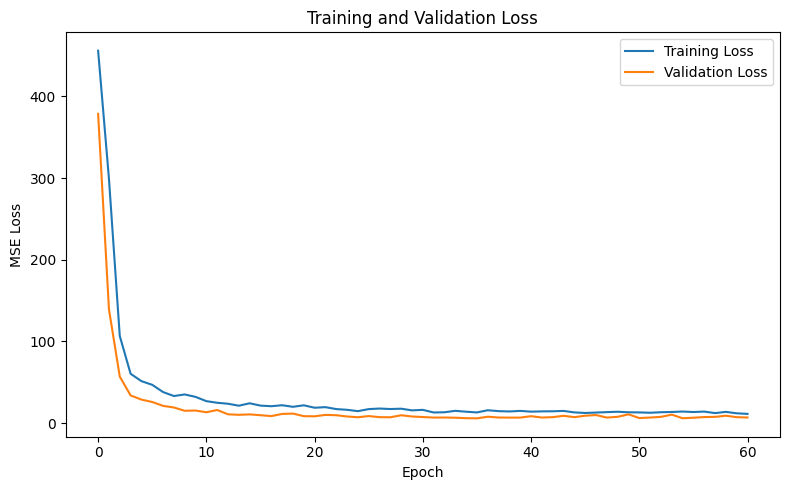

Saved: report_figures/training_loss.png


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "training_loss.png")

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

In [ ]:
y_pred = model.predict(X_test).flatten()

print(y_pred[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
[ 3.2724054  3.1497514 23.884771  30.014763   1.4664167  7.1720324
 -2.720915  25.803722  19.6208    49.64388  ]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R2  :", round(r2,3))

MAE : 2.522
RMSE: 3.765
R2  : 0.965


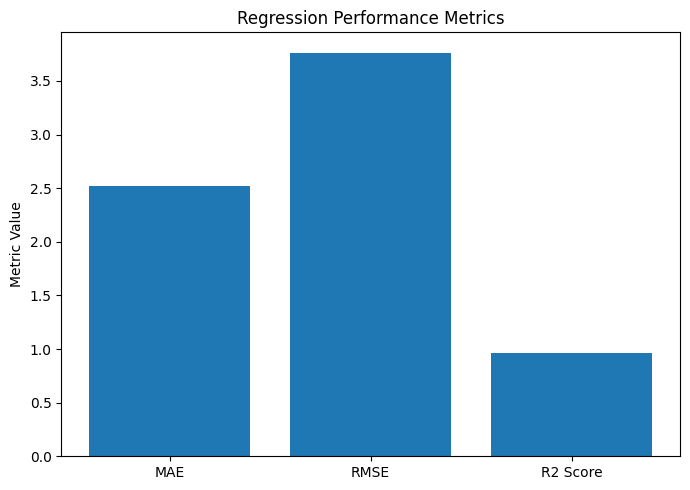

Saved: report_figures/model_metrics.png


In [ ]:
metrics_names = ['MAE', 'RMSE', 'R2 Score']
metrics_values = [mae, rmse, r2]

plt.figure(figsize=(7,5))

plt.bar(metrics_names, metrics_values)

plt.ylabel("Metric Value")
plt.title("Regression Performance Metrics")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "model_metrics.png")

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

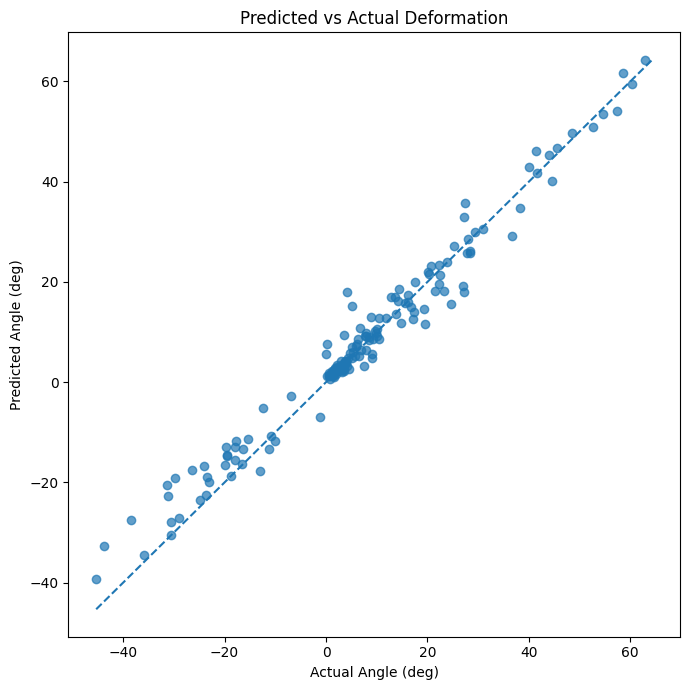

Saved: report_figures/predicted_vs_actual.png


In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Angle (deg)")
plt.ylabel("Predicted Angle (deg)")

plt.title("Predicted vs Actual Deformation")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "predicted_vs_actual.png")

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

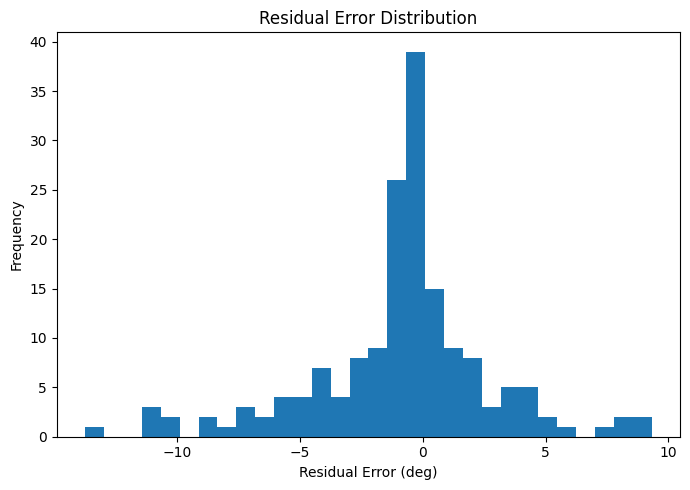

Saved: report_figures/residual_distribution.png


In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error (deg)")
plt.ylabel("Frequency")

plt.title("Residual Error Distribution")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "residual_distribution.png")

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

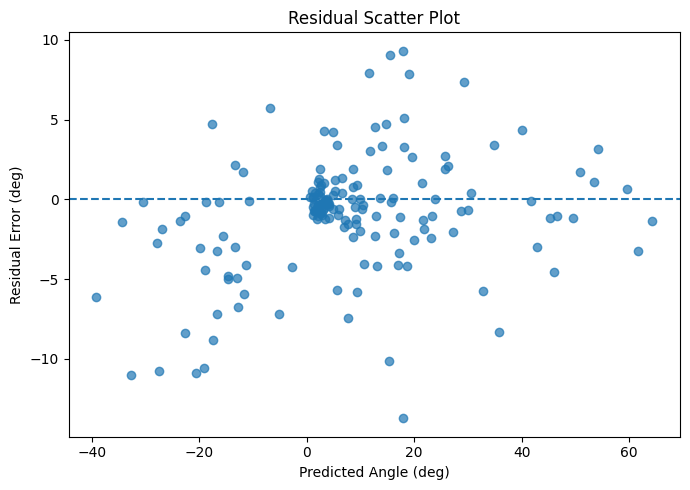

Saved: report_figures/residual_scatter.png


In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Angle (deg)")
plt.ylabel("Residual Error (deg)")

plt.title("Residual Scatter Plot")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "residual_scatter.png")

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

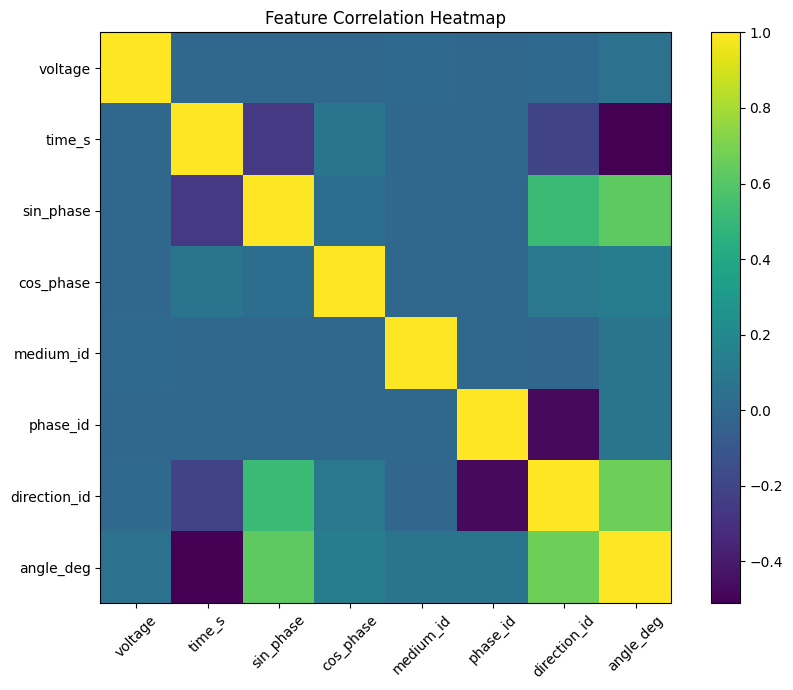

Saved: report_figures/feature_correlation_heatmap.png


In [ ]:
corr_cols = [
    'voltage',
    'time_s',
    'sin_phase',
    'cos_phase',
    'medium_id',
    'phase_id',
    'direction_id',
    'angle_deg'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9,7))

im = plt.imshow(corr_matrix)

plt.colorbar(im)

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

save_path = os.path.join(
    SAVE_DIR,
    "feature_correlation_heatmap.png"
)

plt.savefig(save_path, dpi=600)

plt.show()

print("Saved:", save_path)

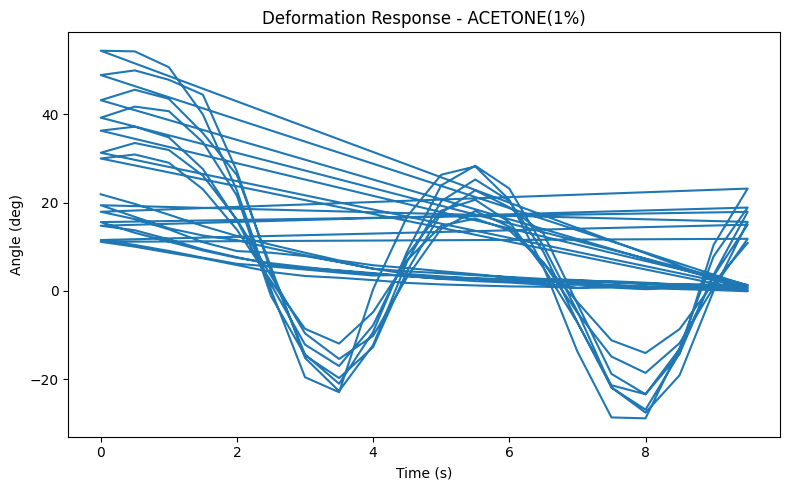

Saved: report_figures/medium_prediction_ACETONE(1%).png


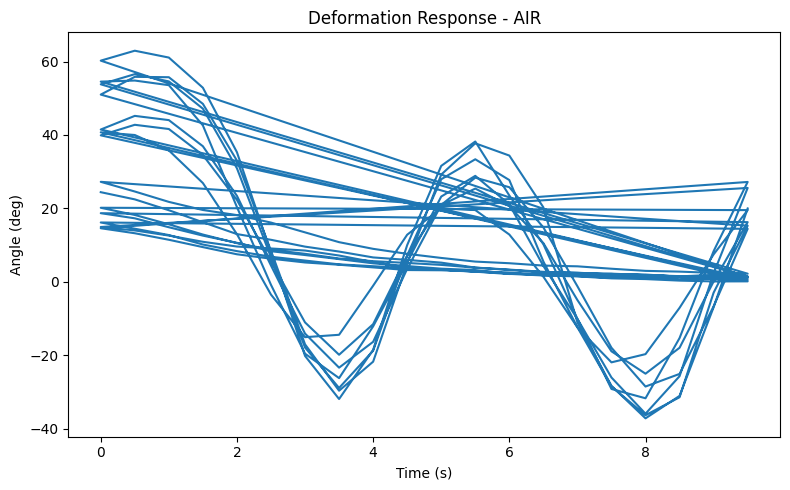

Saved: report_figures/medium_prediction_AIR.png


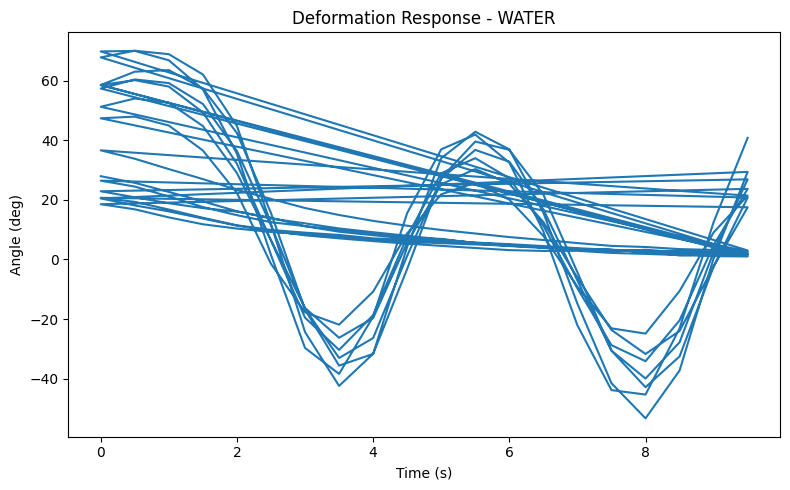

Saved: report_figures/medium_prediction_WATER.png


In [ ]:
mediums = df['medium'].unique()

for medium in mediums:

    subset = df[df['medium'] == medium]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset['time_s'],
        subset['angle_deg']
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Angle (deg)")

    plt.title(f"Deformation Response - {medium}")

    plt.tight_layout()

    filename = f"medium_prediction_{medium}.png"

    save_path = os.path.join(SAVE_DIR, filename)

    plt.savefig(save_path, dpi=600)

    plt.show()

    print("Saved:", save_path)

In [ ]:
model.save("ipmc_dnn_model.h5")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
results_df = pd.DataFrame({

    'Actual_Angle': y_test.values,
    'Predicted_Angle': y_pred,
    'Residual': residuals

})

results_df.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction CSV saved.")

Prediction CSV saved.


In [ ]:
# ============================================================
# FINAL EXPORT BLOCK
# SAVE ALL GENERATED RESULTS INTO A SINGLE ZIP FILE
# ============================================================

import os
import zipfile
import shutil

# ------------------------------------------------------------
# CREATE EXPORT DIRECTORY
# ------------------------------------------------------------

EXPORT_DIR = "IPMC_ML_Project_Export"

if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR, exist_ok=True)

# ------------------------------------------------------------
# FILES TO EXPORT
# ------------------------------------------------------------

files_to_copy = [

    # Model
    "ipmc_dnn_model.h5",

    # Prediction CSV
    "prediction_results.csv",

]

# ------------------------------------------------------------
# COPY GENERATED FILES
# ------------------------------------------------------------

for file in files_to_copy:

    if os.path.exists(file):

        shutil.copy(file, EXPORT_DIR)

        print(f"Copied: {file}")

    else:

        print(f"Missing: {file}")

# ------------------------------------------------------------
# COPY FIGURES DIRECTORY
# ------------------------------------------------------------

if os.path.exists("report_figures"):

    shutil.copytree(
        "report_figures",
        os.path.join(EXPORT_DIR, "report_figures")
    )

    print("Copied report_figures folder")

else:

    print("report_figures folder not found")

# ------------------------------------------------------------
# SAVE NOTEBOOK SCRIPT
# ------------------------------------------------------------

notebook_script = r"""
# ============================================================
# IPMC MACHINE LEARNING NOTEBOOK
# ============================================================

# This project includes:
# - Data preprocessing
# - Feature scaling
# - DNN regression
# - Performance evaluation
# - Residual analysis
# - Correlation analysis
# - Figure export
# ============================================================
"""

with open(
    os.path.join(EXPORT_DIR, "README.txt"),
    "w"
) as f:

    f.write(notebook_script)

print("README created")

# ------------------------------------------------------------
# CREATE ZIP FILE
# ------------------------------------------------------------

zip_filename = "IPMC_ML_Project.zip"

with zipfile.ZipFile(
    zip_filename,
    'w',
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(EXPORT_DIR):

        for file in files:

            file_path = os.path.join(root, file)

            arcname = os.path.relpath(
                file_path,
                EXPORT_DIR
            )

            zipf.write(file_path, arcname)

print("\n====================================")
print("ZIP FILE CREATED SUCCESSFULLY")
print("====================================")

print(f"Saved as: {zip_filename}")

# ------------------------------------------------------------
# OPTIONAL DOWNLOAD (COLAB)
# ------------------------------------------------------------

try:

    from google.colab import files

    files.download(zip_filename)

except:

    print("\nIf running locally, ZIP file is saved in current directory.")

Copied: ipmc_dnn_model.h5
Copied: prediction_results.csv
Copied report_figures folder
README created

ZIP FILE CREATED SUCCESSFULLY
Saved as: IPMC_ML_Project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>